# Exercise 2

##### Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import timeit


# Part 1

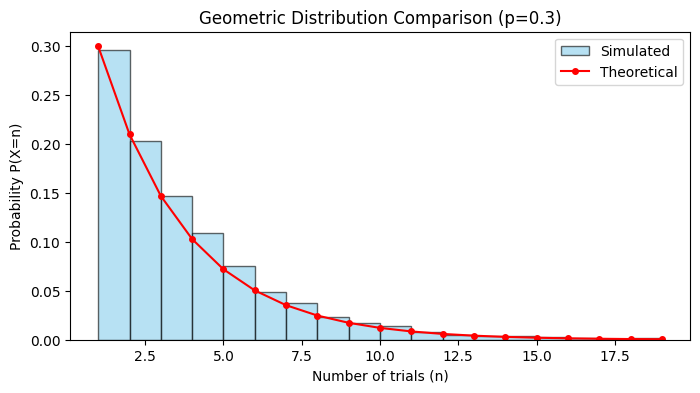

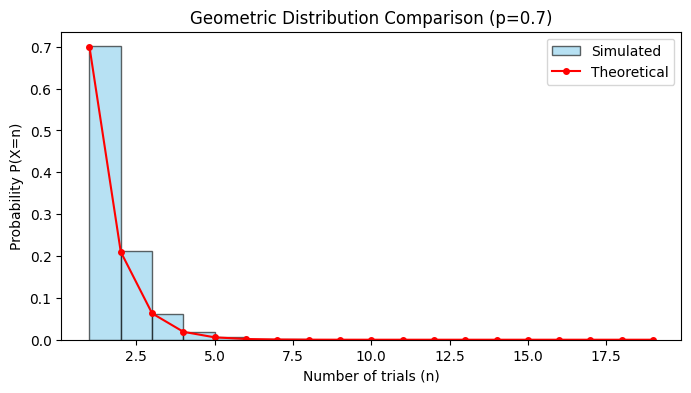

In [ ]:
def sample_geometric(p, n=10000):
    u = np.random.uniform(0, 1, n)
    return np.floor(np.log(u) / np.log(1 - p)) + 1

def plot_geometric_comparison(p):
    samples = sample_geometric(p)
    
    plt.figure(figsize=(8, 4))
    
    plt.hist(samples, bins=range(1, 20), density=True, alpha=0.6, 
             label='Simulated', color='skyblue', edgecolor='black')
    
    # Theoretical PMF: f(n) = (1-p)^(n-1)p 
    n_values = np.arange(1, 20)
    theoretical = (1 - p)**(n_values - 1) * p
    plt.plot(n_values, theoretical, 'ro-', label='Theoretical', markersize=4)
    
    plt.title(f'Geometric Distribution Comparison (p={p})')
    plt.xlabel('Number of trials (n)')
    plt.ylabel('Probability P(X=n)')
    plt.legend()
    plt.show()

# Perform simulation for small and large p values
plot_geometric_comparison(0.3) 
plot_geometric_comparison(0.7)

# Part 2

##### Direct (Crude) Method

In [8]:
def direct_method(n, p):
    # Calculate CDF
    cdf = np.cumsum(p)
    samples = []
    for _ in range(n):
        u = np.random.uniform(0, 1)
        # Find index where u <= cdf
        x = np.searchsorted(cdf, u) + 1
        samples.append(x)
    return np.array(samples)

##### Rejection Method

In [ ]:
def rejection_method(n, p, c=0.35):
    k = len(p)
    samples = []
    while len(samples) < n:
        i = np.random.randint(0, k) 
        u = np.random.uniform(0, 1)
        if u <= p[i] / c: # Accept if U <= p_i/c 
            samples.append(i + 1)
    return np.array(samples)

##### Alias Method

In [10]:
def alias_setup(p):
    k = len(p)
    alias = np.zeros(k, dtype=int)
    prob = np.array(p) * k
    small = [i for i, pr in enumerate(prob) if pr < 1]
    large = [i for i, pr in enumerate(prob) if pr >= 1]
    
    while small and large:
        s, l = small.pop(), large.pop()
        alias[s] = l
        prob[l] = (prob[l] + prob[s]) - 1
        if prob[l] < 1: small.append(l)
        else: large.append(l)
    return prob, alias

def alias_method(n, prob_table, alias_table):
    k = len(prob_table)
    samples = []
    for _ in range(n):
        i = np.random.randint(0, k)
        if np.random.uniform(0, 1) < prob_table[i]:
            samples.append(i + 1)
        else:
            samples.append(alias_table[i] + 1)
    return np.array(samples)

In [11]:
p = np.array([7/48, 5/48, 6/48, 3/48, 12/48, 15/48])
n = 10000

# Setup Alias
prob_table, alias_table = alias_setup(p)

# Sample
s1 = direct_method(n, p)
s2 = rejection_method(n, p)
s3 = alias_method(n, prob_table, alias_table)

In [14]:
time_direct = timeit.timeit(lambda: direct_method(n, p), number=10)
time_rejection = timeit.timeit(lambda: rejection_method(n, p), number=10)
time_alias = timeit.timeit(lambda: alias_method(n, prob_table, alias_table), number=10)

print(f"Direct Method Time: {time_direct:.4f}s")
print(f"Rejection Method Time: {time_rejection:.4f}s")
print(f"Alias Method Time: {time_alias:.4f}s")

Direct Method Time: 0.9302s
Rejection Method Time: 2.0666s
Alias Method Time: 0.9585s
